In [46]:
from sklearn.datasets import load_breast_cancer
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [47]:
# Data loading
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Data splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [48]:
# MLPClassifier Model with default parameters
mlp = MLPClassifier(random_state=42)
mlp.fit(X_train, y_train)

MLPClassifier(random_state=42)

In [49]:
print("Accuracy on training set: {:.2f}".format(mlp.score(X_train, y_train)))
print("Accuracy on test set: {:.2f}".format(mlp.score(X_test, y_test)))

Accuracy on training set: 0.94
Accuracy on test set: 0.92


The accuracy of the MLP is quite good, but not as good as the other models. As when SVC was used on this same dataset, this is likely due to scaling of the data. Neural networks also expect all input features to vary in a similar way, and ideally to have a mean of 0, and a variance of 1. We must rescale our data so that it fulfills these requirements.

In [50]:
print("Cancer data maximum value per-feature :\n{}".format(cancer.data.max(axis=0)))

Cancer data maximum value per-feature :
[2.811e+01 3.928e+01 1.885e+02 2.501e+03 1.634e-01 3.454e-01 4.268e-01
 2.012e-01 3.040e-01 9.744e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 3.113e-02 1.354e-01 3.960e-01 5.279e-02 7.895e-02 2.984e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 1.058e+00 1.252e+00 2.910e-01
 6.638e-01 2.075e-01]


In [51]:
# compute the mean value per feature on the training set
mean_on_train = X_train.mean(axis=0)
# compute the standard deviation of each feature on the training set
std_on_train = X_train.std(axis=0)

# subtract the mean, and scale by inverse standard deviation
# afterward, mean=0 and std=1
X_train_scaled = (X_train - mean_on_train) / std_on_train
# use THE SAME transformation (using training mean and std) on the test set
X_test_scaled = (X_test - mean_on_train) / std_on_train

In [52]:
mlp1 = MLPClassifier(random_state=0)
mlp1.fit(X_train_scaled, y_train)

print("Accuracy on training set: {:.3f}".format(mlp1.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp1.score(X_test_scaled, y_test)))

Accuracy on training set: 0.993
Accuracy on test set: 0.965


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


The results are much better after scaling, and already quite competitive. We got a warning from the model, though, that tells us that the maximum number of iterations has been reached. This is part of the **adam algorithm** for learning the model, and tells us that we should increase the number of iterations.

In [53]:
mlp1 = MLPClassifier(max_iter=1000, random_state=0)
mlp1.fit(X_train_scaled, y_train)

print("Accuracy on training set: {:.3f}".format(mlp1.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp1.score(X_test_scaled, y_test)))

Accuracy on training set: 0.998
Accuracy on test set: 0.965


Increasing the number of iterations only increased the training set performance, not the generalization performance. Still, the model is performing quite well. As there is some gap between the training and the test performance, we might try to decrease the model’s complexity to get better generalization performance. Here, we choose to increase the alpha parameter (quite aggressively, from 0.0001 to 1) to add stronger regularization of the weights.

In [54]:
mlp2 = MLPClassifier(max_iter=1000, alpha=1, random_state=0)
mlp2.fit(X_train_scaled, y_train)

print("Accuracy on training set: {:.3f}".format(mlp2.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp2.score(X_test_scaled, y_test)))

Accuracy on training set: 0.988
Accuracy on test set: 0.986


it is possible to analyze what a neural network has learned, this is usually much trickier than analyzing a linear model or a tree-based model. One way to inspect what was learned is to look at the weights in the model.

Below plot shows the weights that were learned connecting the input to the first hidden layer. The rows in this plot correspond to the 30 input features, while the columns correspond to the 100 hidden units. Light colors represent large positive values, while dark colors represent negative values.

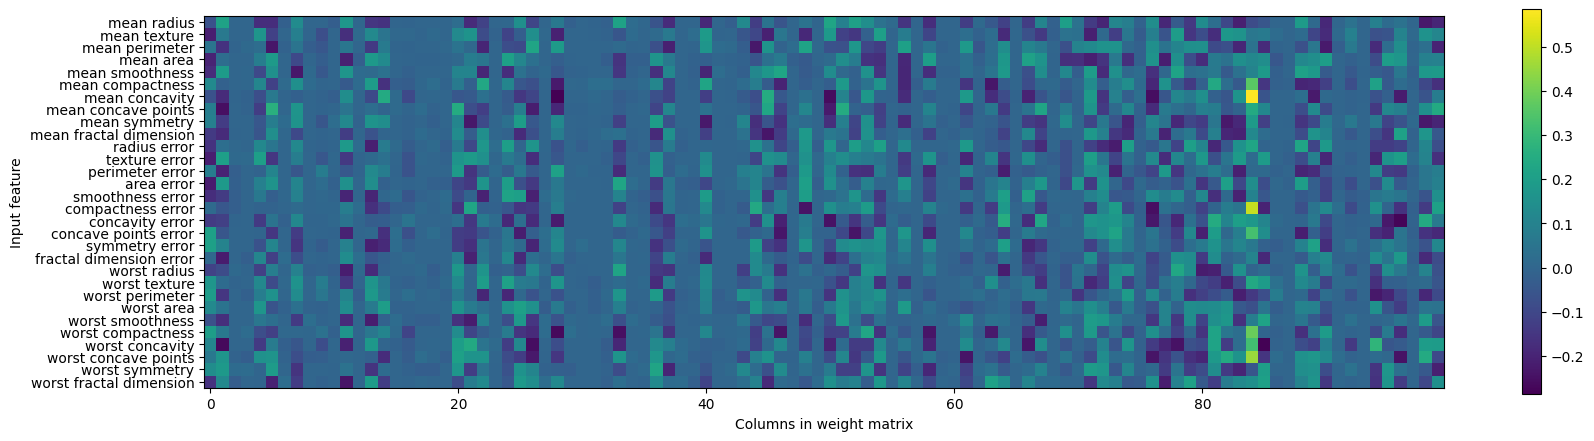

In [55]:
plt.figure(figsize=(20, 5))
plt.imshow(mlp.coefs_[0], interpolation='none', cmap='viridis')
plt.yticks(range(30), cancer.feature_names)
plt.xlabel("Columns in weight matrix")
plt.ylabel("Input feature")
plt.colorbar()

One possible inference we can make is that features that have very small weights for all of the hidden units are “less important” to the model.